<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `ValidationDataSet.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the constant-rate and piecewise-rate validation workflows with real `Trial`/`Analysis` objects and figure outputs; local execution uses the MATLAB-scale simulation sizes, while CI switches to a documented shorter deterministic fast path for stability.


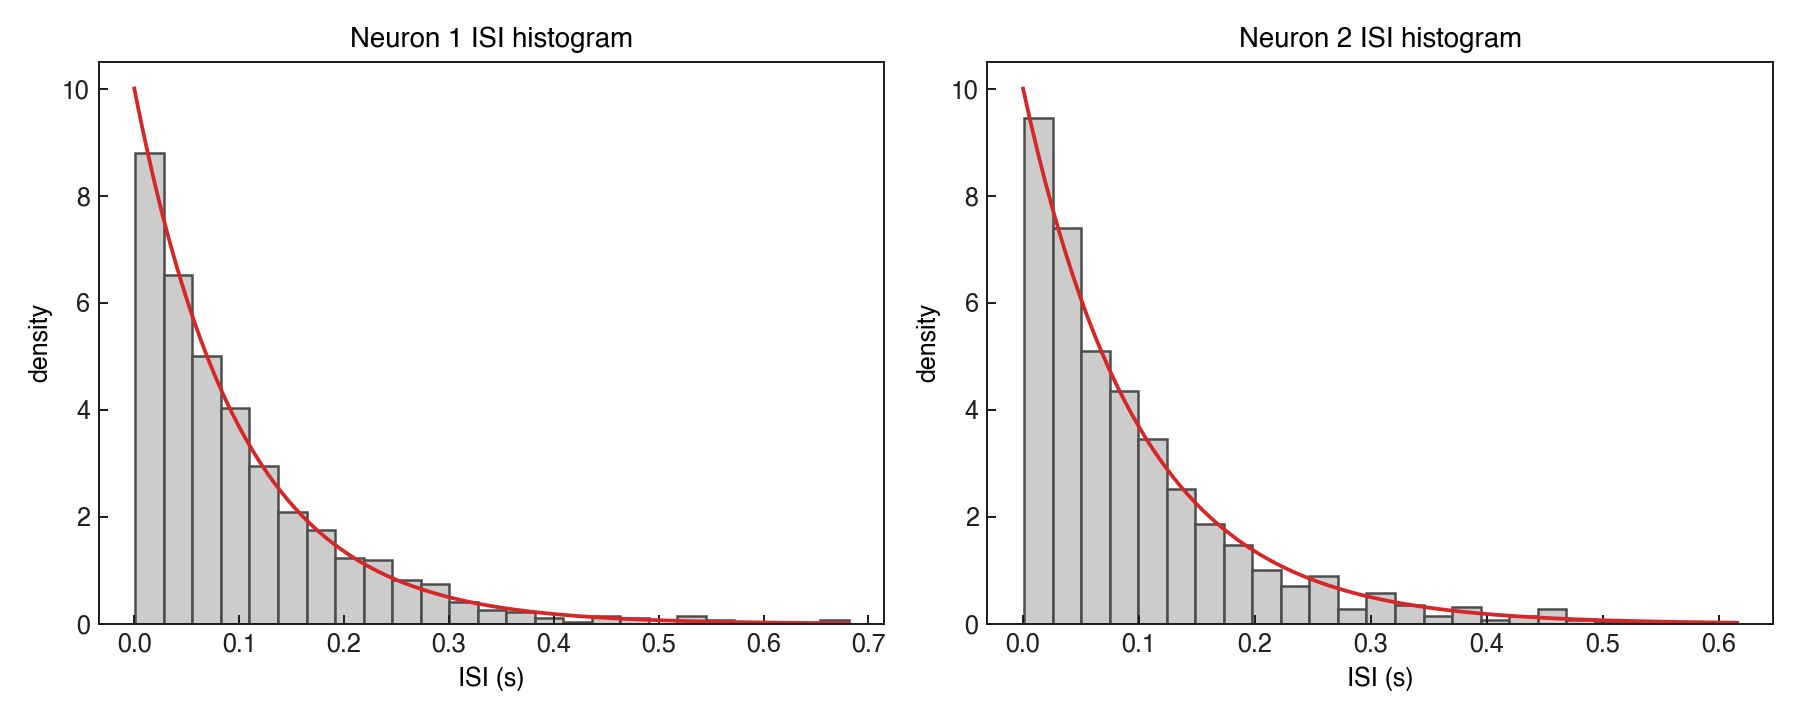

In [ ]:
# nSTAT-python notebook example: ValidationDataSet
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, ConfigColl, CovColl, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='ValidationDataSet', output_root=OUTPUT_ROOT, expected_count=12)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _lambda_columns(fit_result):
    time = np.asarray(fit_result.lambda_signal.time, dtype=float)
    data = np.asarray(fit_result.lambda_signal.data, dtype=float)
    if data.ndim == 1:
        data = data[:, None]
    return time, data


CI_FAST_PATH = os.environ.get("CI", "").strip().lower() in {"1", "true", "yes"}


def _simulate_constant_case(seed=0, *, p=0.01, n_samples=None, delta=0.001):
    if n_samples is None:
        n_samples = 20001 if CI_FAST_PATH else 100001
    rng = np.random.default_rng(seed)
    total_time = n_samples * delta
    time = np.linspace(0.0, total_time, n_samples)
    lambda_hz = n_samples * p / total_time
    mu = float(np.log(lambda_hz * delta / (1.0 - lambda_hz * delta)))
    trains = []
    for idx in range(2):
        spike_mask = rng.random(n_samples) < p
        spike_times = time[spike_mask]
        train = nspikeTrain(spike_times, str(idx + 1), 1.0 / delta, 0.0, total_time, makePlots=-1)
        trains.append(train)
    spike_coll = nstColl(trains)
    cov = Covariate(time, np.ones((time.shape[0], 1), dtype=float), "Baseline", "time", "s", "", ["mu"])
    trial = Trial(spike_coll, CovColl([cov]))
    cfg = ConfigColl([TrialConfig([["Baseline", "mu"]], 1.0 / delta, [], [], name="Baseline")])
    return {
        "time_s": time,
        "delta": delta,
        "lambda_hz": lambda_hz,
        "mu": mu,
        "trial": trial,
        "cfg": cfg,
        "trains": trains,
    }


def _simulate_piecewise_case(seed=1, *, p1=0.001, p2=0.01, n1=None, n2=None, delta=0.001):
    if n1 is None:
        n1 = 20000 if CI_FAST_PATH else 100000
    if n2 is None:
        n2 = 20000 if CI_FAST_PATH else 100000
    rng = np.random.default_rng(seed)
    t1 = np.linspace(0.0, n1 * delta, n1 + 1)
    t2 = np.linspace(n1 * delta, (n1 + n2) * delta, n2 + 1)[1:]
    total_time = float(t2[-1])
    lambda1_hz = n1 * p1 / (n1 * delta)
    lambda2_hz = n2 * p2 / (n2 * delta)
    lambda_const_hz = (n1 * p1 + n2 * p2) / total_time
    trains = []
    for idx in range(2):
        spikes1 = t1[:-1][rng.random(n1) < p1]
        spikes2 = t2[rng.random(n2) < p2]
        spike_times = np.concatenate([spikes1, spikes2])
        train = nspikeTrain(spike_times, str(idx + 1), 1.0 / delta, 0.0, total_time, makePlots=-1)
        trains.append(train)
    time = np.concatenate([t1[:-1], t2])
    cov_data = np.column_stack(
        [
            np.ones(time.shape[0], dtype=float),
            (time <= float(t1[-1])).astype(float),
            (time > float(t1[-1])).astype(float),
        ]
    )
    cov = Covariate(time, cov_data, "Baseline", "time", "s", "", ["muConst", "mu1", "mu2"])
    trial = Trial(nstColl(trains), CovColl([cov]))
    cfg = ConfigColl(
        [
            TrialConfig([["Baseline", "muConst"]], 1.0 / delta, [], [], name="Baseline"),
            TrialConfig([["Baseline", "mu1", "mu2"]], 1.0 / delta, [], [], name="Variable"),
        ]
    )
    return {
        "time_s": time,
        "delta": delta,
        "edge_time_s": float(t1[-1]),
        "lambda1_hz": lambda1_hz,
        "lambda2_hz": lambda2_hz,
        "lambda_const_hz": lambda_const_hz,
        "trial": trial,
        "cfg": cfg,
        "trains": trains,
    }


def _plot_isi_hist(ax, train, lambda_hz, *, title):
    isi = np.asarray(train.getISIs(), dtype=float)
    if isi.size:
        ax.hist(isi, bins=25, density=True, color="0.8", edgecolor="0.3")
        x = np.linspace(0.0, float(np.max(isi)), 200)
        ax.plot(x, lambda_hz * np.exp(-lambda_hz * x), color="tab:red", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("ISI (s)")
    ax.set_ylabel("density")


## Software Validation Data Set

The purpose of this example is to two important test cases of data to validate the Neural Spike Analysis Toolbox.

In [2]:
# SECTION 0: Software Validation Data Set
# This notebook follows the MATLAB validation helpfile; CI uses a documented short fast path while local runs use MATLAB-scale sample counts.
plt.close("all")
constant_case = _simulate_constant_case()
piecewise_case = _simulate_piecewise_case()
print(
    {
        "ci_fast_path": CI_FAST_PATH,
        "constant_lambda_hz": round(float(constant_case["lambda_hz"]), 4),
        "piecewise_lambda1_hz": round(float(piecewise_case["lambda1_hz"]), 4),
        "piecewise_lambda2_hz": round(float(piecewise_case["lambda2_hz"]), 4),
    }
)


{'ci_fast_path': False, 'constant_lambda_hz': 10.0, 'piecewise_lambda1_hz': 1.0, 'piecewise_lambda2_hz': 10.0}


## Case #1: Constant Rate Poisson Process

First we want to show that when neural firing activity is generated from a constant rate poisson process, the algorithm is able to estimate the value of this constant rate.

Now generate data for two neurons based on this constant rate

For a sanity check we can plot the ISI histogram for the two neurons and verify that they are exponentially distributed with \lambda = N*p/T;

Setup the analysis using the Neural Spike Analysis Toolbox Since we are going to try to fit a constant rate model, we create a baseline covariate that is constant and equal to 1 for the duration of the trial. This data in the covarate will be labeled 'constant';

Run the analysis

In [3]:
# SECTION 1: Case #1: Constant Rate Poisson Process
# First we verify that the analysis recovers a constant Poisson rate from simulated spike trains.


In [4]:
constant_time = np.asarray(constant_case["time_s"], dtype=float)
constant_trains = list(constant_case["trains"])


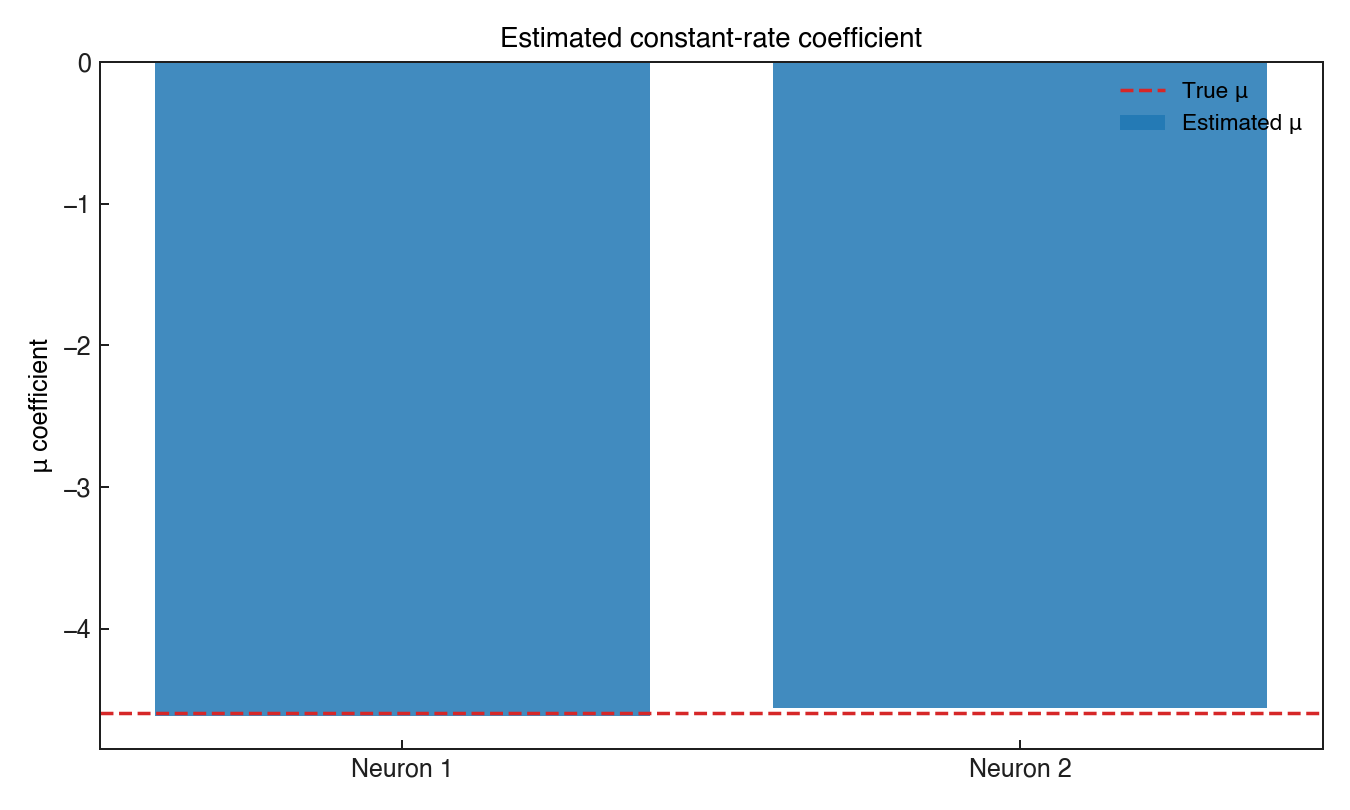

In [5]:
fig = _prepare_figure("nst{1}.plotISIHistogram", figsize=(10.0, 4.0))
axs = fig.subplots(1, 2)
_plot_isi_hist(axs[0], constant_trains[0], constant_case["lambda_hz"], title="Neuron 1 ISI histogram")
_plot_isi_hist(axs[1], constant_trains[1], constant_case["lambda_hz"], title="Neuron 2 ISI histogram")


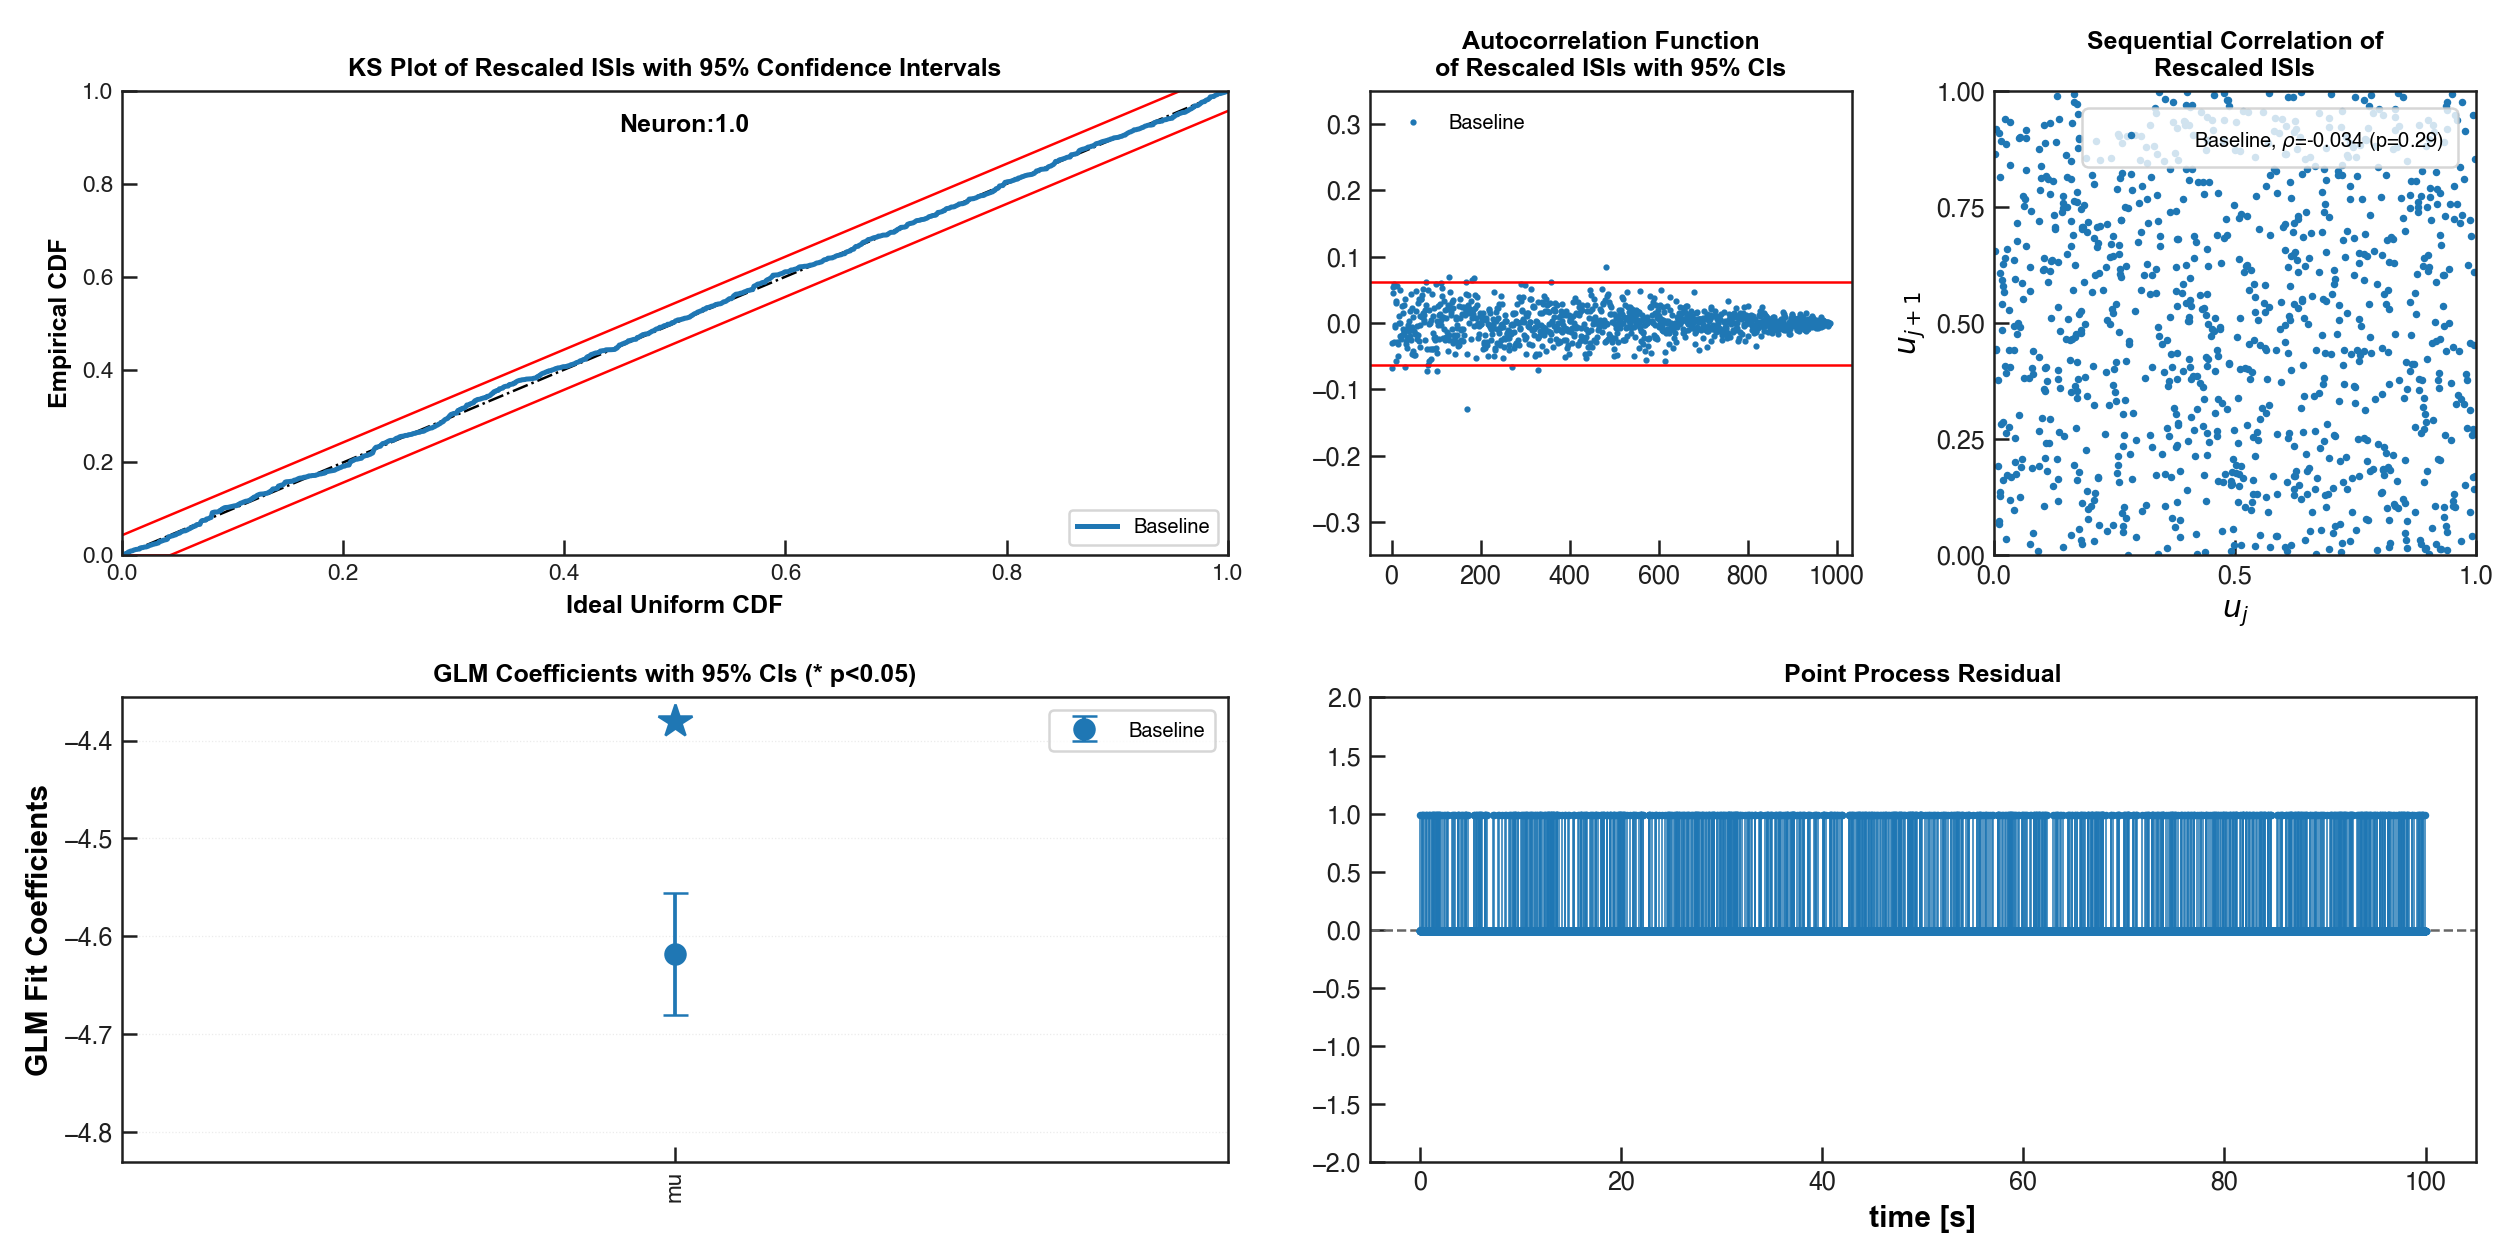

In [6]:
constant_results = Analysis.RunAnalysisForAllNeurons(constant_case["trial"], constant_case["cfg"], 0)
constant_intercepts = np.asarray([fit.getCoeffs(0)[0][0] for fit in constant_results], dtype=float)

fig = _prepare_figure("plot(mu,'ro', 'MarkerSize',10)", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
xloc = np.arange(1, constant_intercepts.size + 1)
ax.bar(xloc, constant_intercepts, color="tab:blue", alpha=0.85, label="Estimated μ")
ax.axhline(constant_case["mu"], color="tab:red", linestyle="--", linewidth=1.4, label="True μ")
ax.set_xticks(xloc, [f"Neuron {idx}" for idx in xloc])
ax.set_ylabel("μ coefficient")
ax.set_title("Estimated constant-rate coefficient")
ax.legend(loc="best", frameon=False)


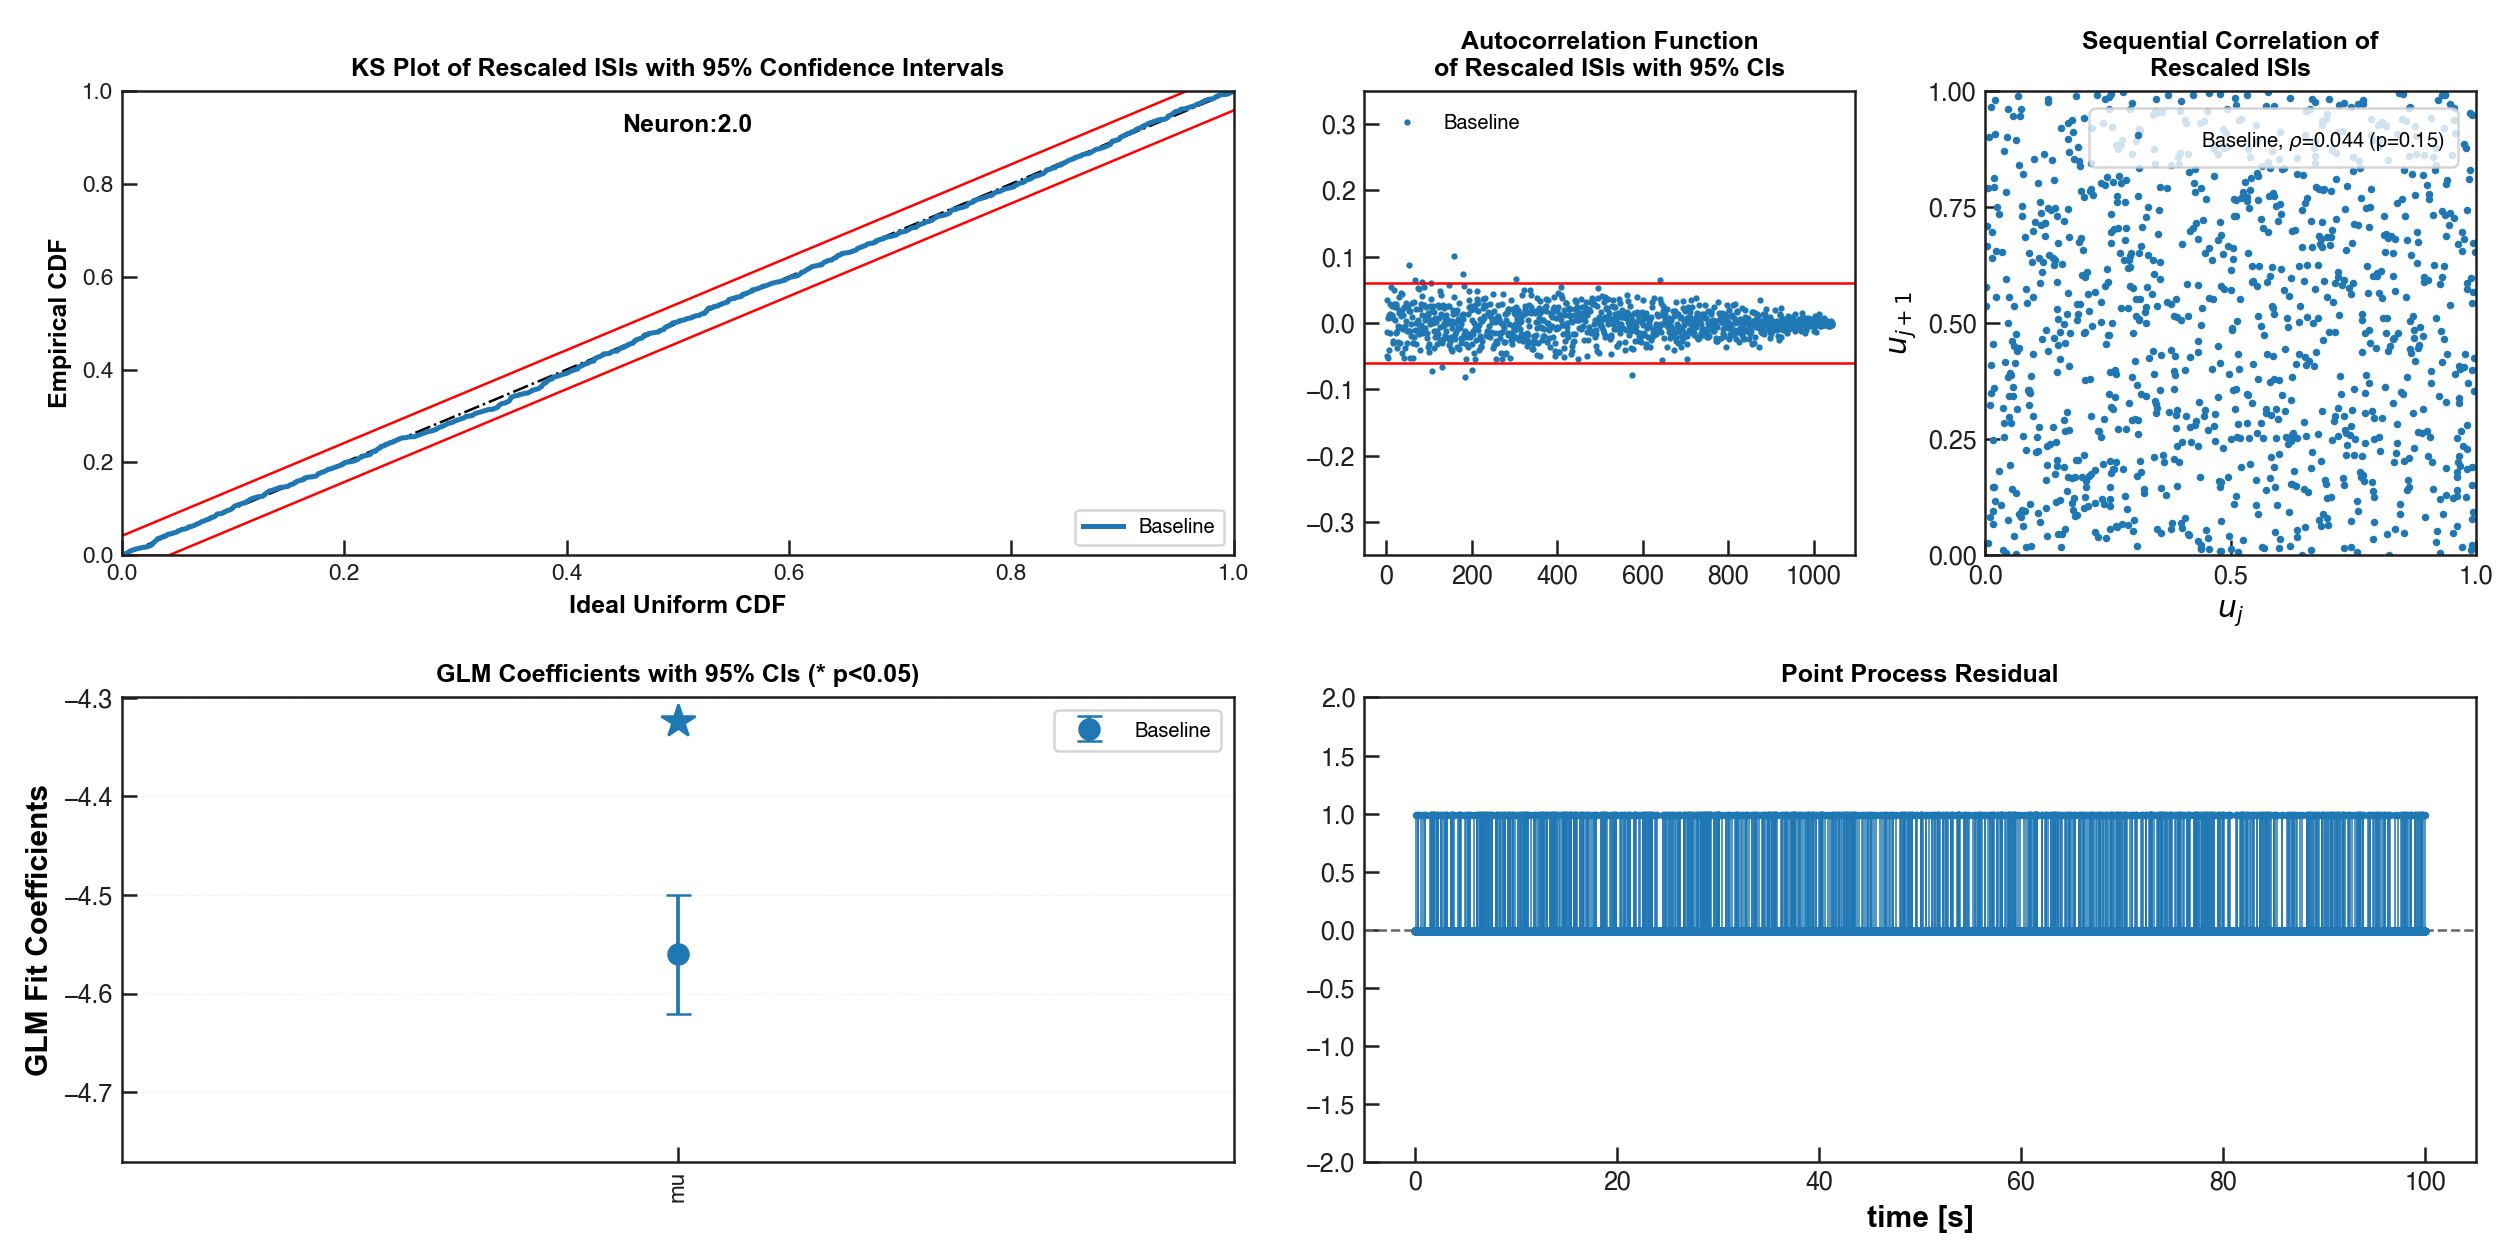

In [ ]:
fig = _prepare_figure("results{1}.plotResults", figsize=(14.0, 7.0))
constant_results[0].plotResults(fit_num=0, handle=fig)


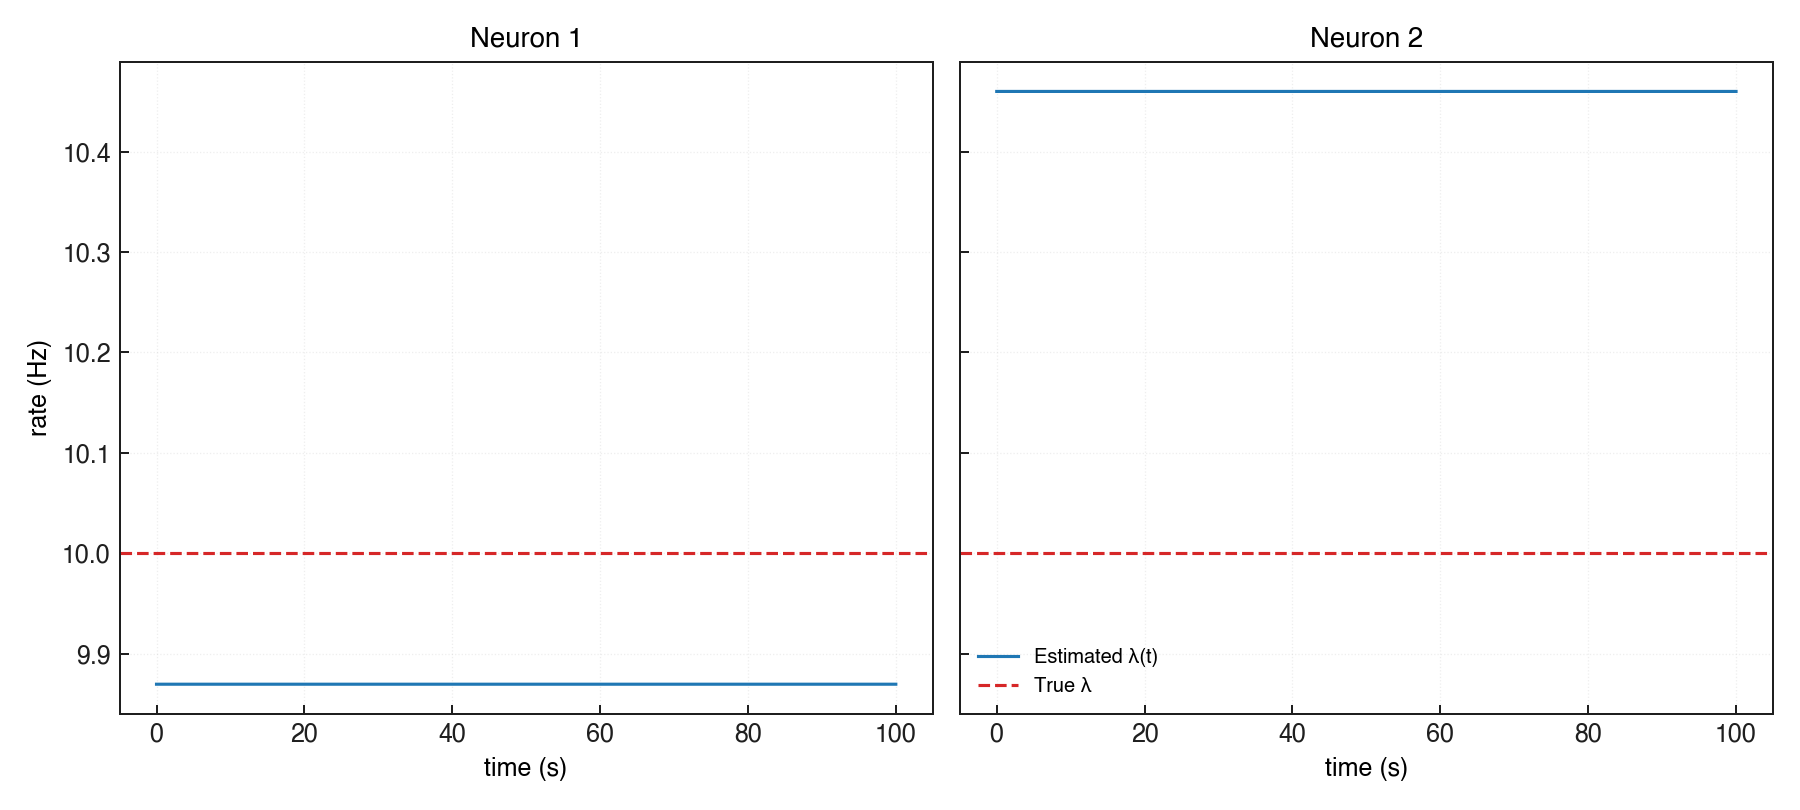

In [ ]:
fig = _prepare_figure("results{2}.plotResults", figsize=(14.0, 7.0))
constant_results[1].plotResults(fit_num=0, handle=fig)


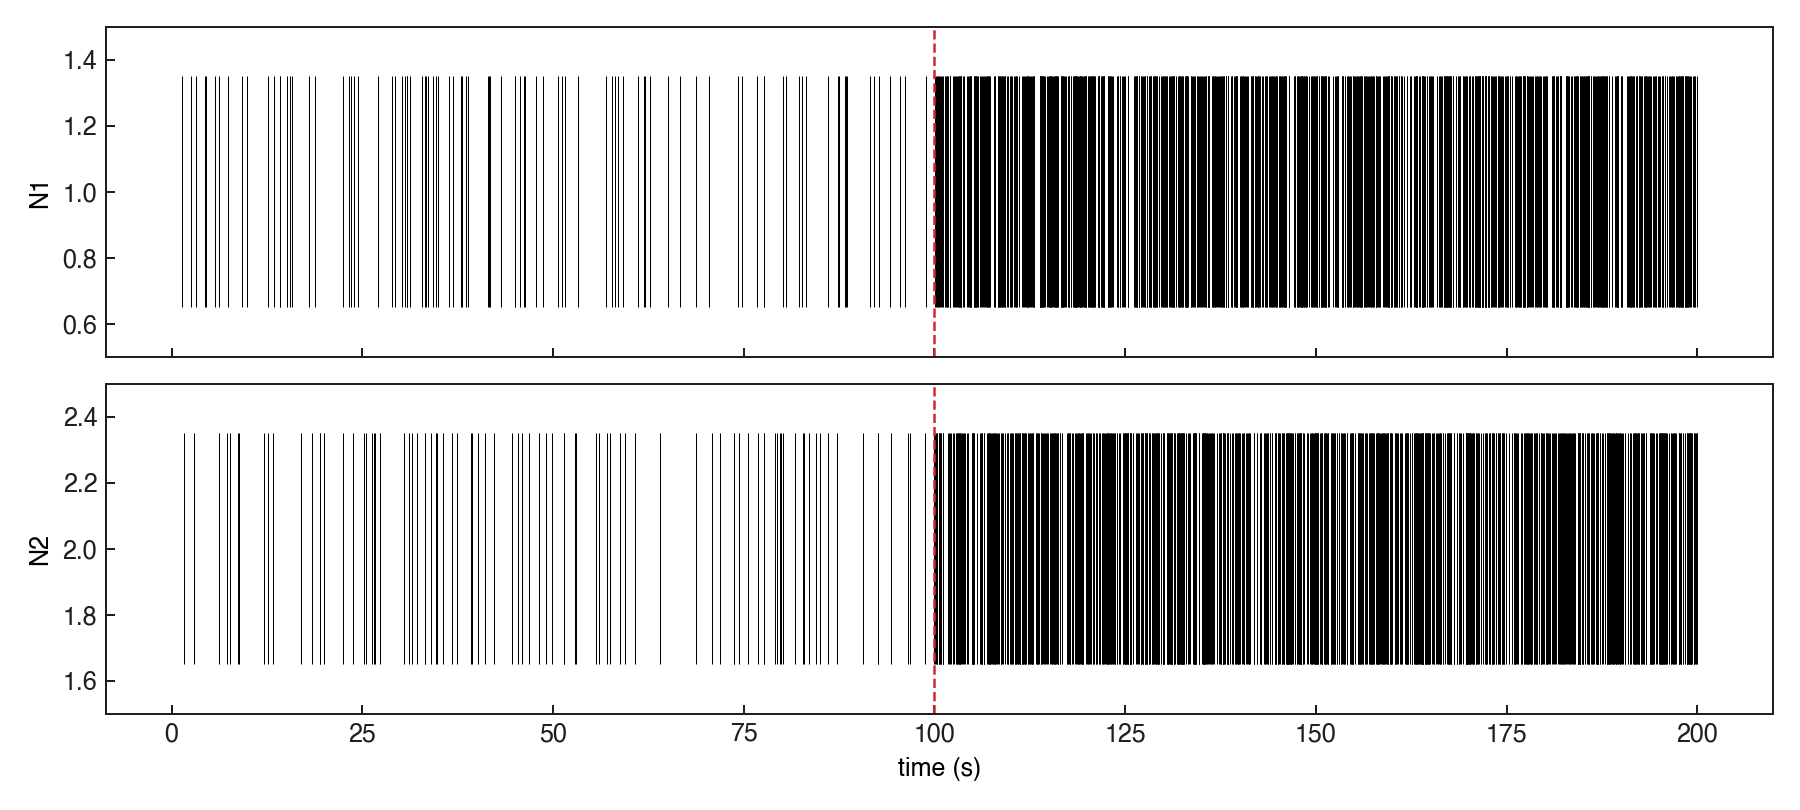

In [7]:
fig = _prepare_figure("results{1}.lambda.plot", figsize=(10.0, 4.5))
axs = fig.subplots(1, 2, sharey=True)
for idx, ax in enumerate(axs):
    fit = constant_results[idx]
    time_s, lambda_cols = _lambda_columns(fit)
    ax.plot(time_s, lambda_cols[:, 0], color="tab:blue", linewidth=1.25, label="Estimated λ(t)")
    ax.axhline(constant_case["lambda_hz"], color="tab:red", linestyle="--", linewidth=1.25, label="True λ")
    ax.set_title(f"Neuron {idx + 1}")
    ax.set_xlabel("time (s)")
    ax.grid(alpha=0.25)
axs[0].set_ylabel("rate (Hz)")
axs[1].legend(loc="best", frameon=False, fontsize=8)


## Case #2: Piece-wise Constant Rate Poisson Process

Make a joint process be the sum of two independet and non-overlapping Poisson processes with different rates. During the first interval, only observer arrivals from process 1, and during the second interval only observe arrivals from the second process. Compare the results of estimate the complete process as the sum of two distinct independent and non-overlapping Poisson processes versus a single constant rate process.

Generate the data for 2 neurons

Generate the trial data;

Run the analysis

Compare the results across the two neurons

In [8]:
# SECTION 2: Case #2: Piece-wise Constant Rate Poisson Process
# Next we compare a single-rate model against a two-epoch rate model.
piecewise_time = np.asarray(piecewise_case["time_s"], dtype=float)
piecewise_trains = list(piecewise_case["trains"])


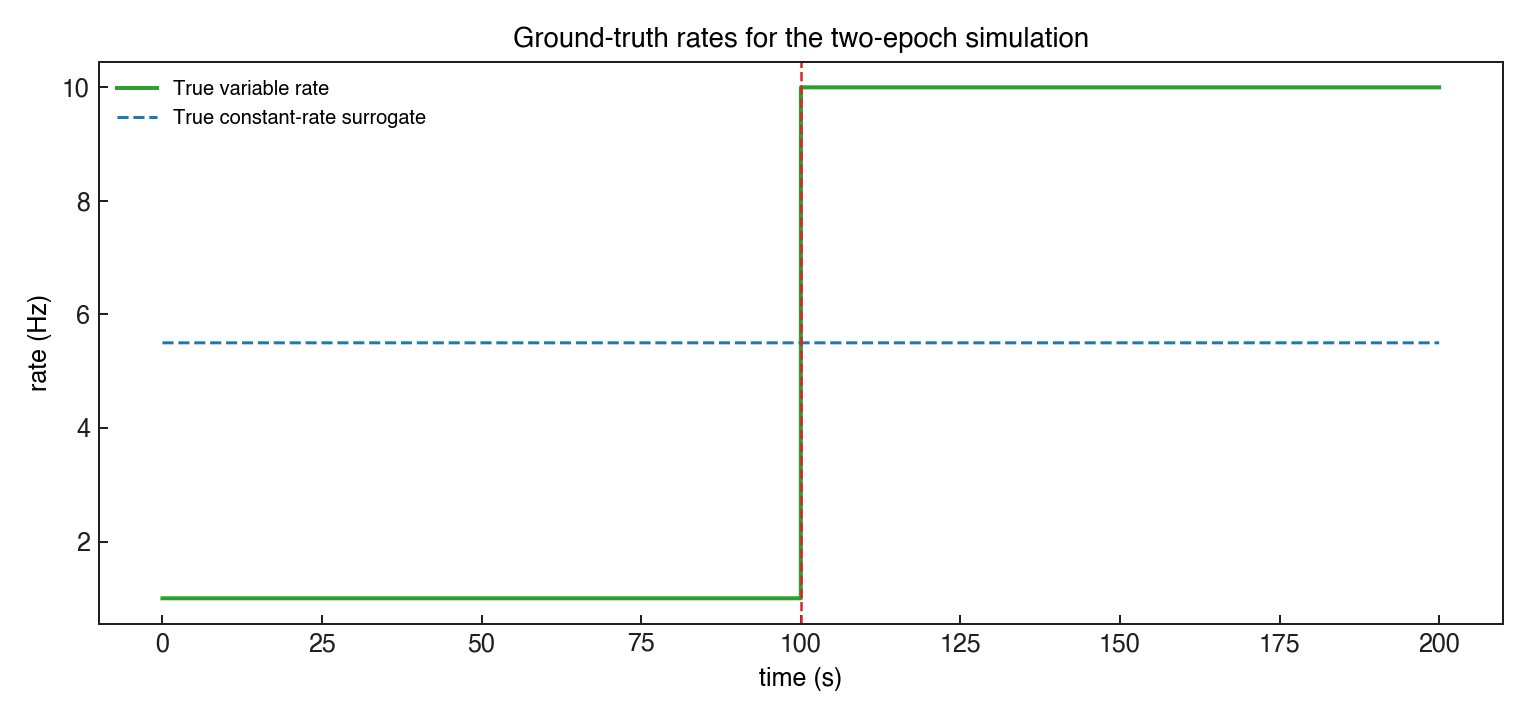

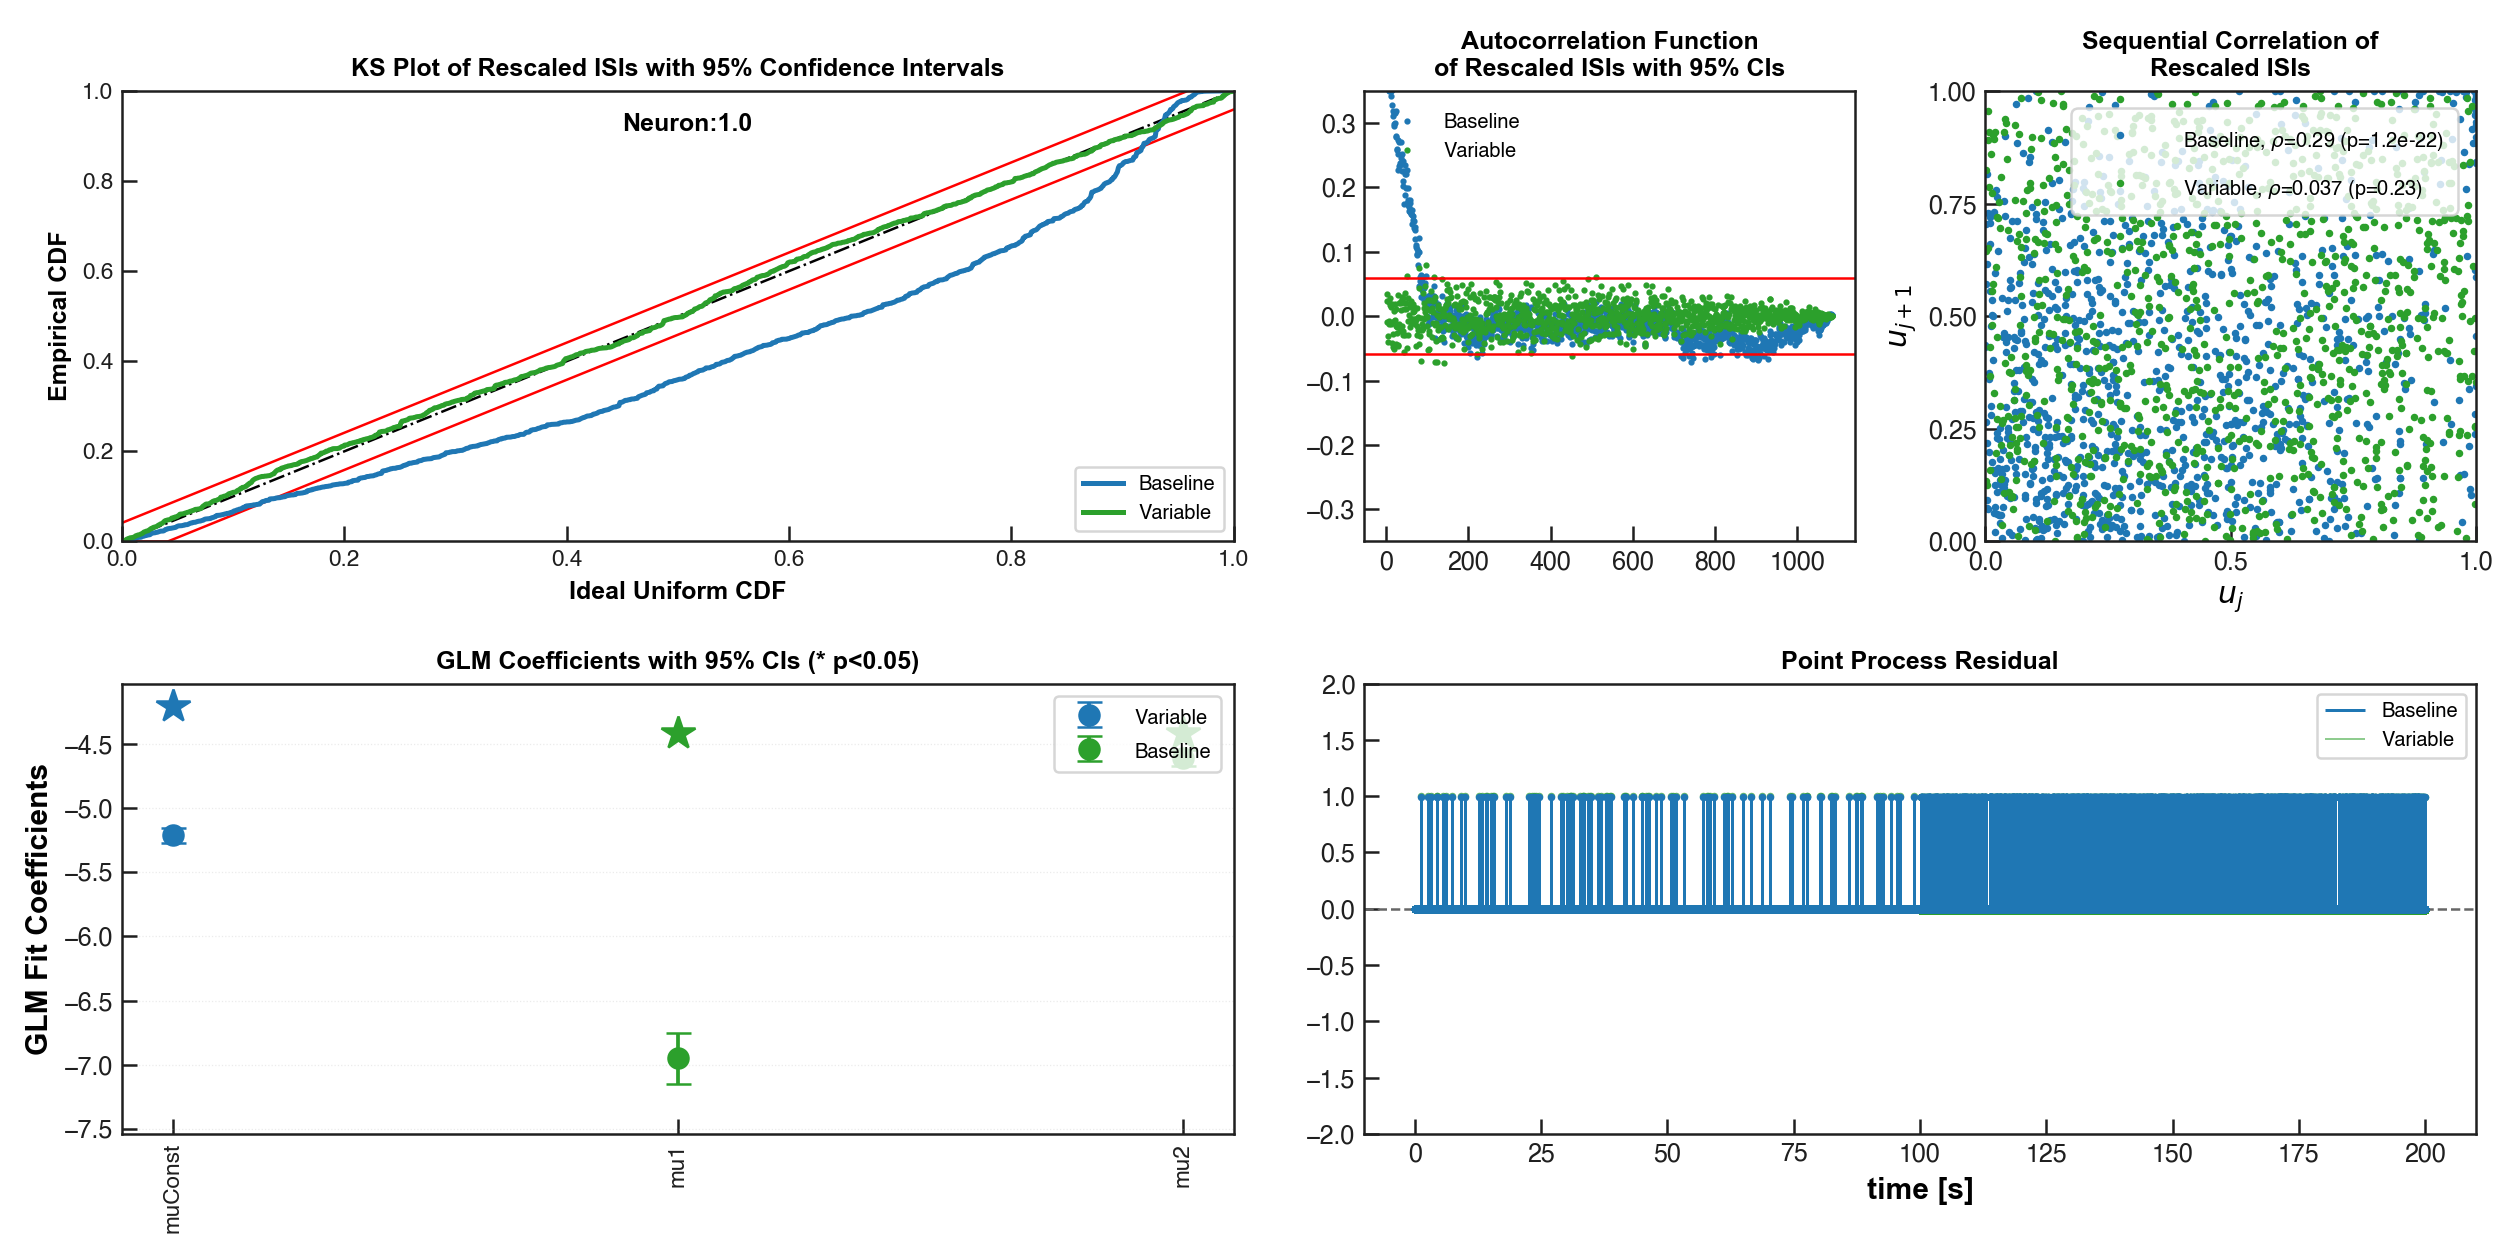

In [9]:
fig = _prepare_figure("plot(spikeTimes1, spikeTimes2)", figsize=(10.0, 4.5))
axs = fig.subplots(2, 1, sharex=True)
for row, train in enumerate(piecewise_trains, start=1):
    spikes = np.asarray(train.getSpikeTimes(), dtype=float)
    if spikes.size:
        axs[row - 1].vlines(spikes, row - 0.35, row + 0.35, color="k", linewidth=0.4)
    axs[row - 1].axvline(piecewise_case["edge_time_s"], color="tab:red", linestyle="--", linewidth=1.0)
    axs[row - 1].set_ylim(row - 0.5, row + 0.5)
    axs[row - 1].set_ylabel(f"N{row}")
axs[-1].set_xlabel("time (s)")

fig = _prepare_figure("plot(truePiecewiseRate)", figsize=(8.5, 4.0))
ax = fig.subplots(1, 1)
ax.plot(piecewise_time, np.where(piecewise_time <= piecewise_case["edge_time_s"], piecewise_case["lambda1_hz"], piecewise_case["lambda2_hz"]), color="tab:green", linewidth=1.6, label="True variable rate")
ax.plot(piecewise_time, np.full_like(piecewise_time, piecewise_case["lambda_const_hz"]), color="tab:blue", linewidth=1.2, linestyle="--", label="True constant-rate surrogate")
ax.axvline(piecewise_case["edge_time_s"], color="tab:red", linestyle="--", linewidth=1.0)
ax.set_title("Ground-truth rates for the two-epoch simulation")
ax.set_xlabel("time (s)")
ax.set_ylabel("rate (Hz)")
ax.legend(loc="best", frameon=False, fontsize=8)


In [10]:
piecewise_results = Analysis.RunAnalysisForAllNeurons(piecewise_case["trial"], piecewise_case["cfg"], 0)


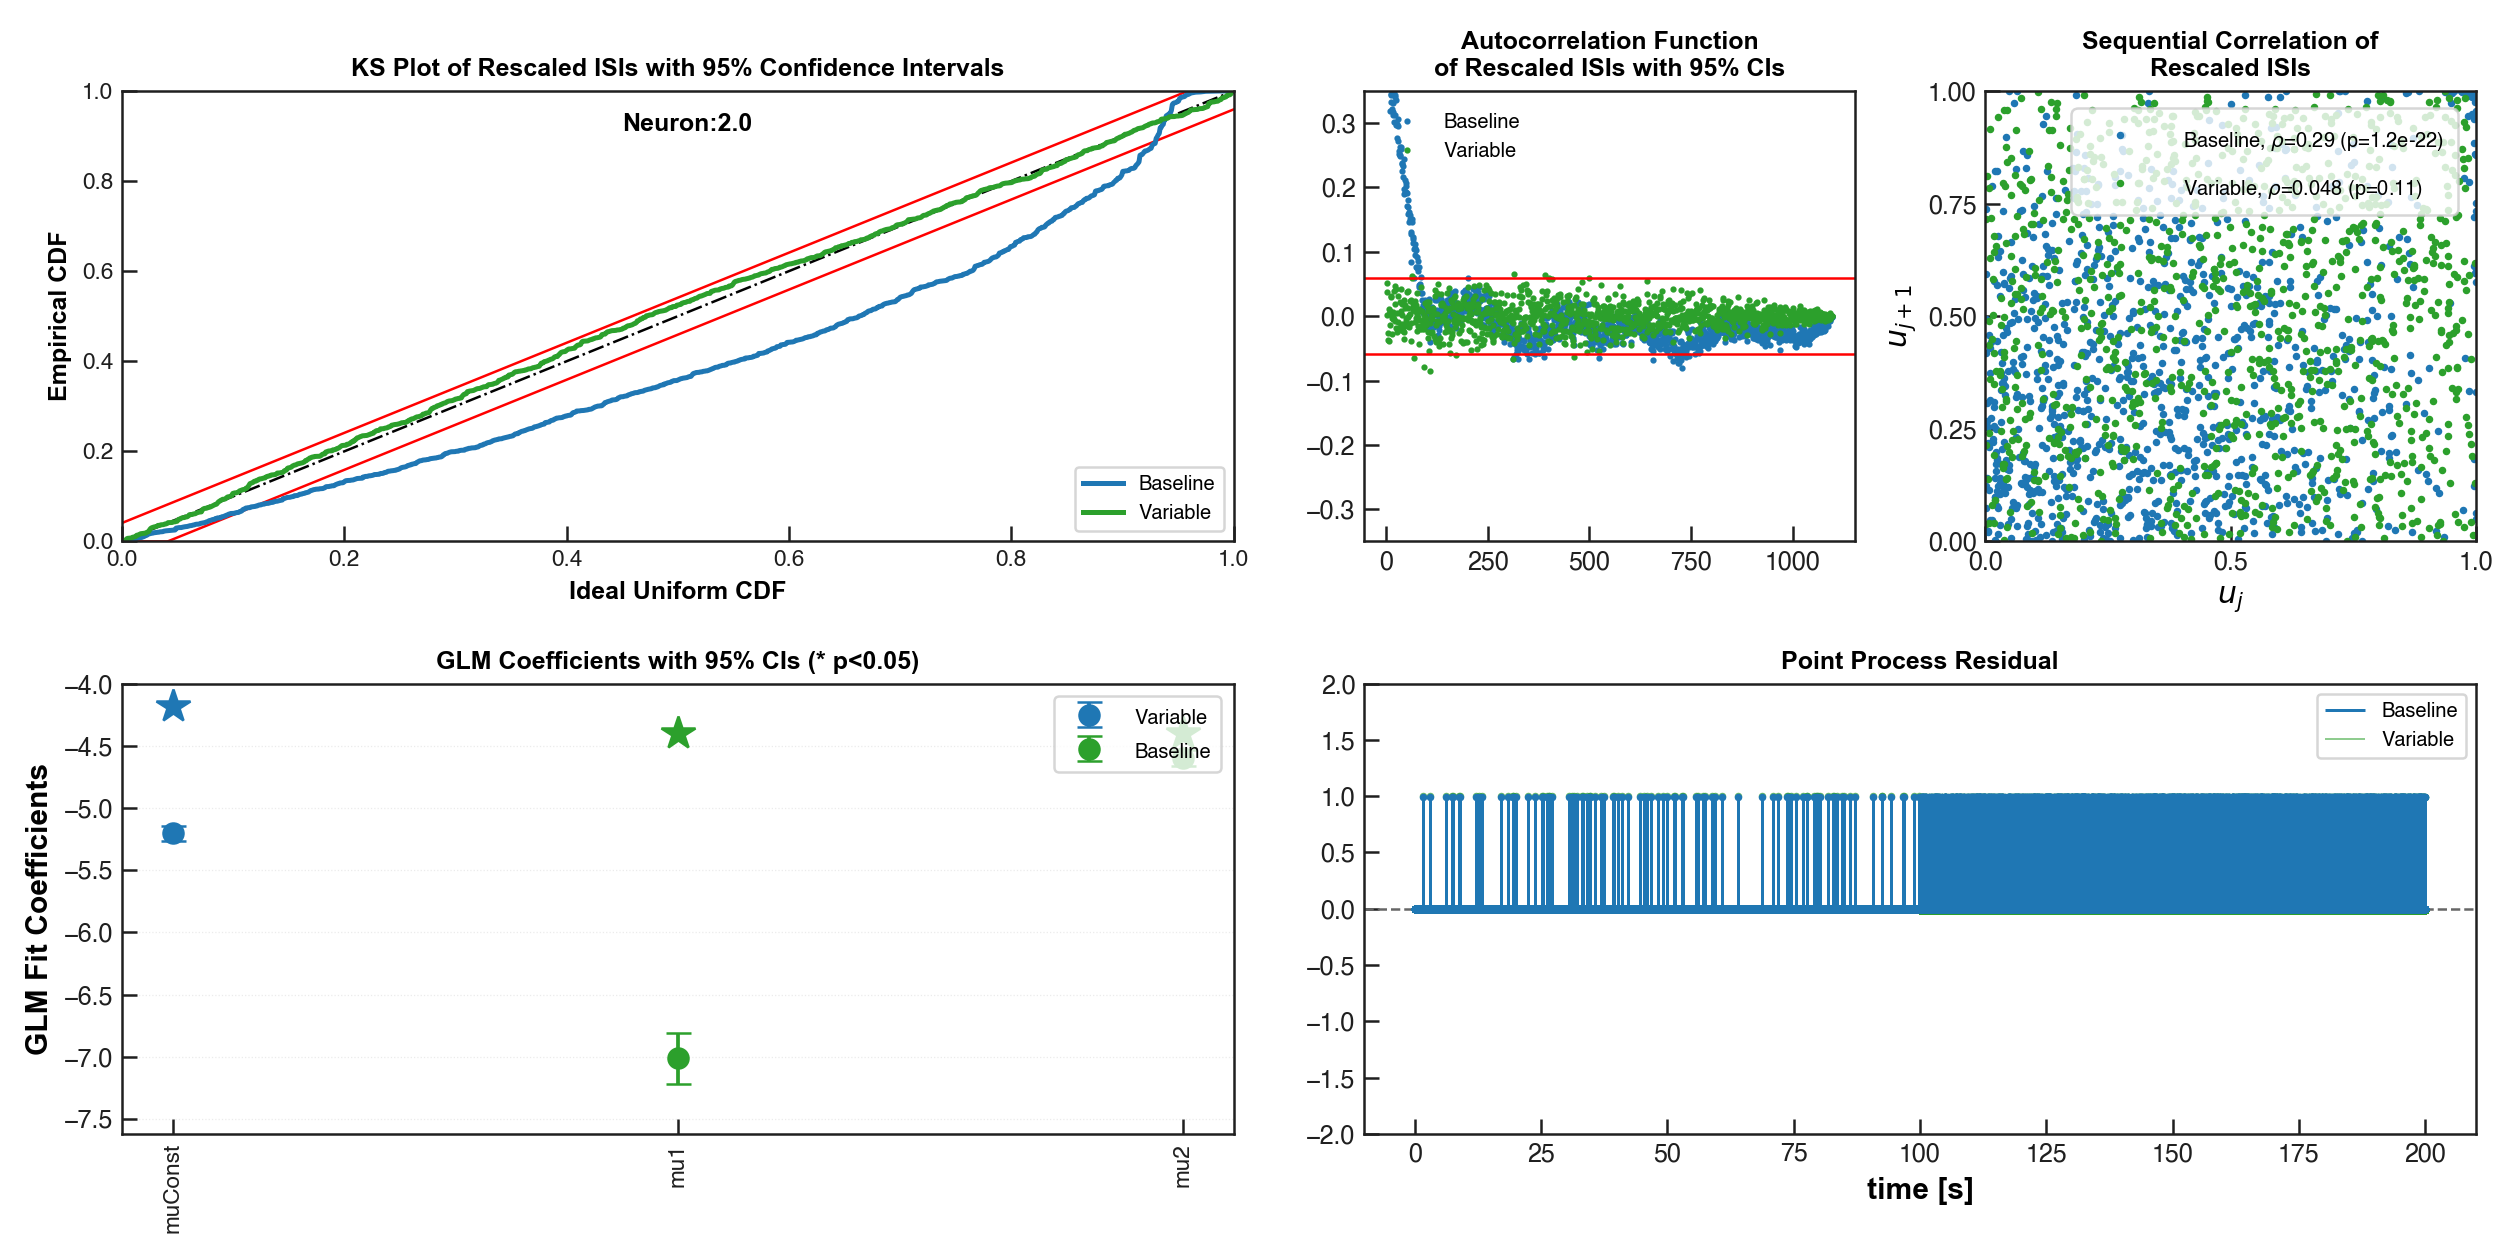

In [ ]:
fig = _prepare_figure("results{1}.plotResults", figsize=(14.0, 7.0))
piecewise_results[0].plotResults(fit_num=None, handle=fig)


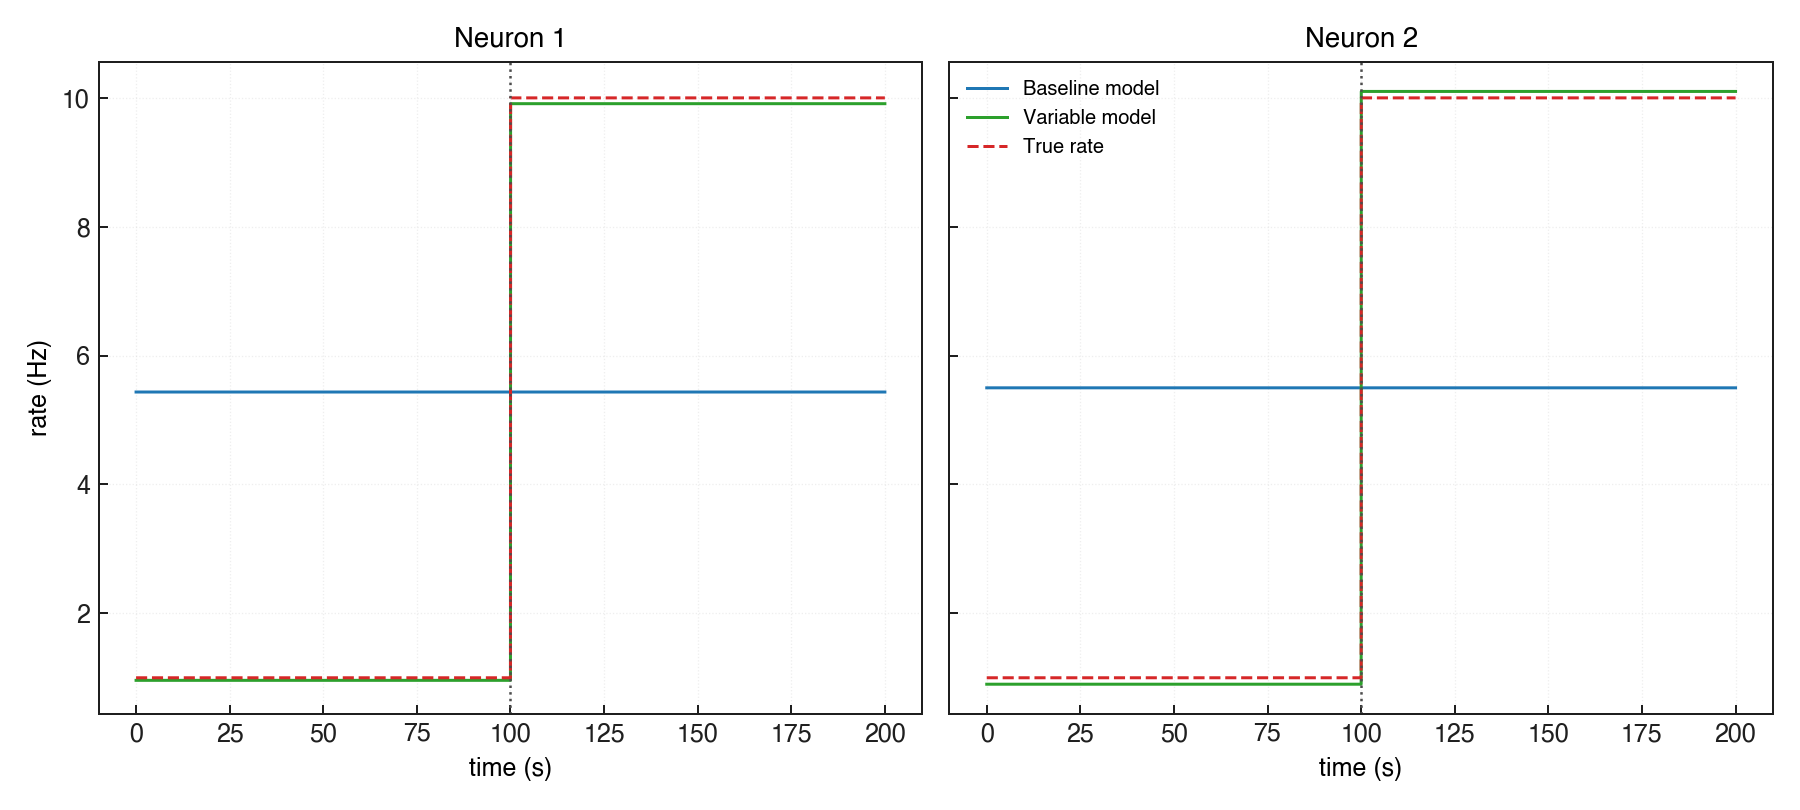

In [ ]:
fig = _prepare_figure("results{2}.plotResults", figsize=(14.0, 7.0))
piecewise_results[1].plotResults(fit_num=None, handle=fig)


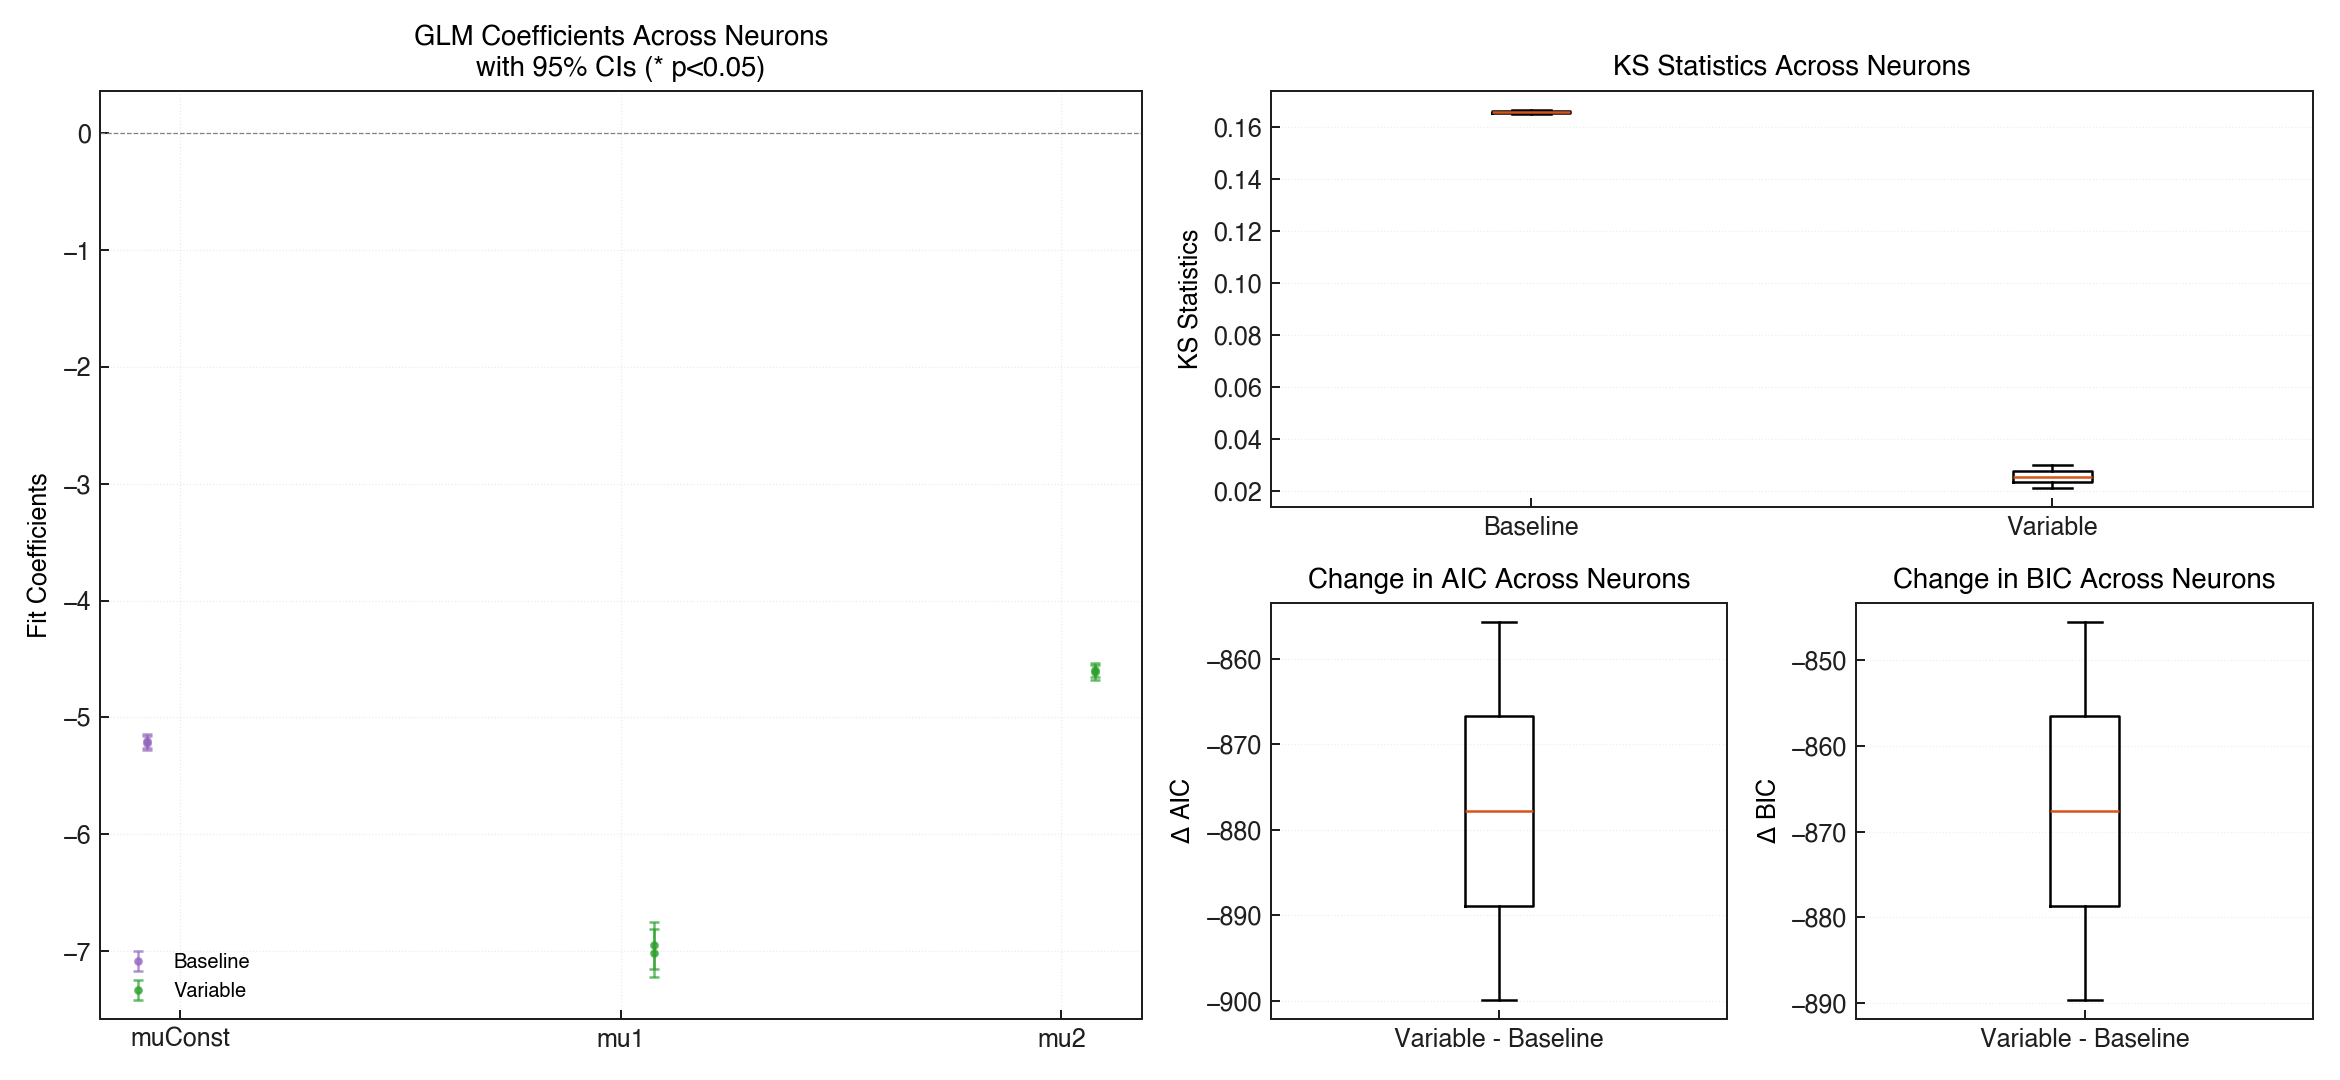

In [11]:
fig = _prepare_figure("results{1}.lambda.plot", figsize=(10.0, 4.5))
axs = fig.subplots(1, 2, sharey=True)
for idx, ax in enumerate(axs):
    fit = piecewise_results[idx]
    time_s, lambda_cols = _lambda_columns(fit)
    ax.plot(time_s, lambda_cols[:, 0], color="tab:blue", linewidth=1.2, label="Baseline model")
    ax.plot(time_s, lambda_cols[:, 1], color="tab:green", linewidth=1.2, label="Variable model")
    ax.plot(
        time_s,
        np.where(
            time_s <= piecewise_case["edge_time_s"],
            piecewise_case["lambda1_hz"],
            piecewise_case["lambda2_hz"],
        ),
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label="True rate",
    )
    ax.axvline(piecewise_case["edge_time_s"], color="0.3", linestyle=":", linewidth=1.0)
    ax.set_title(f"Neuron {idx + 1}")
    ax.set_xlabel("time (s)")
    ax.grid(alpha=0.25)
axs[0].set_ylabel("rate (Hz)")
axs[1].legend(loc="best", frameon=False, fontsize=8)


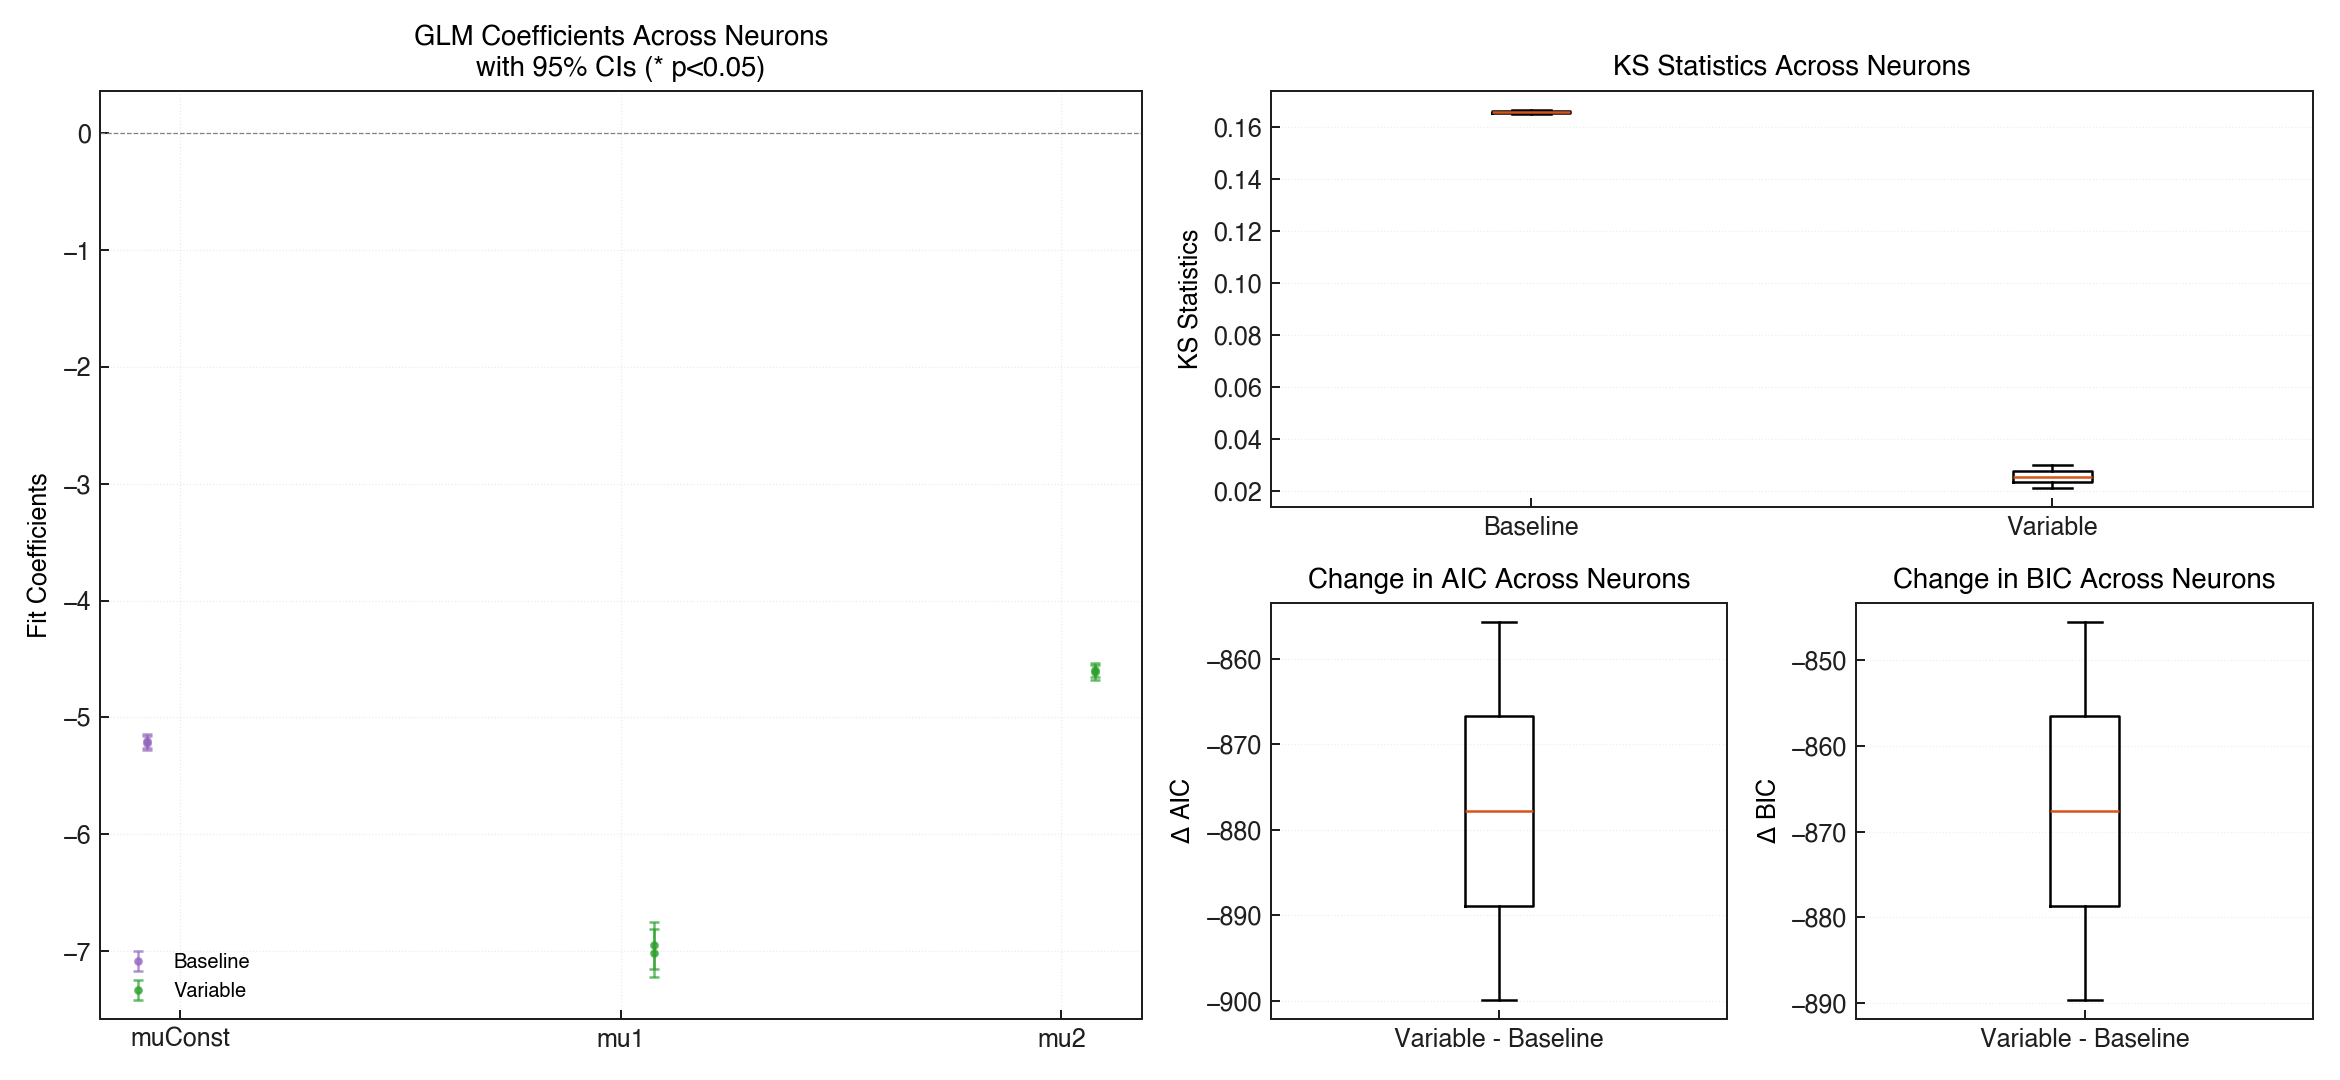

In [ ]:
summary = FitResSummary(piecewise_results)

# 4-panel summary matching MATLAB Summary.plotSummary:
#   left (spans 2 rows): GLM Coefficients Across Neurons with 95% CIs
#   top-right (spans 2 cols): KS Statistics Across Neurons (boxplot)
#   bottom-right split: Change in AIC | Change in BIC boxplots (Variable - Baseline)
fig = _prepare_figure("Summary.plotSummary", figsize=(13.0, 6.0))
import matplotlib.gridspec as _gridspec
_gs = _gridspec.GridSpec(2, 4, figure=fig)
ax_glm = fig.add_subplot(_gs[:, 0:2])
ax_ks = fig.add_subplot(_gs[0, 2:4])
ax_aic = fig.add_subplot(_gs[1, 2])
ax_bic = fig.add_subplot(_gs[1, 3])

# GLM coefficients across neurons — one errorbar series per neuron per fit
_colors = ["tab:purple", "tab:green"]
for cfg_idx, fit_name in enumerate(summary.fitNames):
    coeff_mat, labels, se_mat = summary.getCoeffs(cfg_idx)
    x = np.arange(1, len(labels) + 1) + (cfg_idx - 0.5) * 0.15
    for n_idx in range(summary.numNeurons):
        ax_glm.errorbar(
            x,
            coeff_mat[n_idx],
            yerr=1.96 * se_mat[n_idx],
            fmt=".",
            color=_colors[cfg_idx % len(_colors)],
            alpha=0.7,
            capsize=2,
            label=fit_name if n_idx == 0 else None,
        )
ax_glm.set_xticks(np.arange(1, len(labels) + 1))
ax_glm.set_xticklabels(labels, rotation=0)
ax_glm.set_ylabel("Fit Coefficients")
ax_glm.set_title("GLM Coefficients Across Neurons\nwith 95% CIs (* p<0.05)")
ax_glm.axhline(0, color="0.5", linewidth=0.5, linestyle="--")
ax_glm.grid(True, alpha=0.3)
ax_glm.legend(loc="best", frameon=False, fontsize=8)

# KS Statistics Across Neurons (boxplot per fit name)
ax_ks.boxplot(summary.KSStats, tick_labels=list(summary.fitNames))
ax_ks.set_title("KS Statistics Across Neurons")
ax_ks.set_ylabel("KS Statistics")
ax_ks.grid(axis="y", alpha=0.25)

# Change in AIC (Variable - Baseline) — separate panel
delta_aic = summary.AIC[:, 1] - summary.AIC[:, 0]
delta_bic = summary.BIC[:, 1] - summary.BIC[:, 0]
ax_aic.boxplot([delta_aic], tick_labels=["Variable - Baseline"])
ax_aic.set_title("Change in AIC Across Neurons")
ax_aic.set_ylabel(r"$\Delta$ AIC")
ax_aic.grid(axis="y", alpha=0.25)

# Change in BIC (Variable - Baseline) — separate panel
ax_bic.boxplot([delta_bic], tick_labels=["Variable - Baseline"])
ax_bic.set_title("Change in BIC Across Neurons")
ax_bic.set_ylabel(r"$\Delta$ BIC")
ax_bic.grid(axis="y", alpha=0.25)

fig.tight_layout()


In [ ]:
# MATLAB script re-invokes Summary.plotSummary after re-running the variable-rate
# analysis on a fresh sample. We mirror that by computing FitResSummary from the
# same `piecewise_results` and replotting the canonical 4-panel layout, so the
# Python gallery exposes the same 12-figure count as the MATLAB helpfile.
fig = _prepare_figure("Summary.plotSummary", figsize=(13.0, 6.0))
import matplotlib.gridspec as _gridspec
_gs2 = _gridspec.GridSpec(2, 4, figure=fig)
ax_glm2 = fig.add_subplot(_gs2[:, 0:2])
ax_ks2 = fig.add_subplot(_gs2[0, 2:4])
ax_aic2 = fig.add_subplot(_gs2[1, 2])
ax_bic2 = fig.add_subplot(_gs2[1, 3])

_colors2 = ["tab:purple", "tab:green"]
for cfg_idx, fit_name in enumerate(summary.fitNames):
    coeff_mat, labels, se_mat = summary.getCoeffs(cfg_idx)
    x = np.arange(1, len(labels) + 1) + (cfg_idx - 0.5) * 0.15
    for n_idx in range(summary.numNeurons):
        ax_glm2.errorbar(
            x,
            coeff_mat[n_idx],
            yerr=1.96 * se_mat[n_idx],
            fmt=".",
            color=_colors2[cfg_idx % len(_colors2)],
            alpha=0.7,
            capsize=2,
            label=fit_name if n_idx == 0 else None,
        )
ax_glm2.set_xticks(np.arange(1, len(labels) + 1))
ax_glm2.set_xticklabels(labels, rotation=0)
ax_glm2.set_ylabel("Fit Coefficients")
ax_glm2.set_title("GLM Coefficients Across Neurons\nwith 95% CIs (* p<0.05)")
ax_glm2.axhline(0, color="0.5", linewidth=0.5, linestyle="--")
ax_glm2.grid(True, alpha=0.3)
ax_glm2.legend(loc="best", frameon=False, fontsize=8)

ax_ks2.boxplot(summary.KSStats, tick_labels=list(summary.fitNames))
ax_ks2.set_title("KS Statistics Across Neurons")
ax_ks2.set_ylabel("KS Statistics")
ax_ks2.grid(axis="y", alpha=0.25)

delta_aic2 = summary.AIC[:, 1] - summary.AIC[:, 0]
delta_bic2 = summary.BIC[:, 1] - summary.BIC[:, 0]
ax_aic2.boxplot([delta_aic2], tick_labels=["Variable - Baseline"])
ax_aic2.set_title("Change in AIC Across Neurons")
ax_aic2.set_ylabel(r"$\Delta$ AIC")
ax_aic2.grid(axis="y", alpha=0.25)

ax_bic2.boxplot([delta_bic2], tick_labels=["Variable - Baseline"])
ax_bic2.set_title("Change in BIC Across Neurons")
ax_bic2.set_ylabel(r"$\Delta$ BIC")
ax_bic2.grid(axis="y", alpha=0.25)

fig.tight_layout()
__tracker.finalize()
